In [1]:
import scipy as sp
from pylab import *
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import seaborn as sns
import random
import openpyxl


from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

sns.set_style("ticks")

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}



session_name="results/test"


In [3]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution(k):
    return np.random.exponential(k)

def hiearchy_score_1(DominanceMatrix_BC,competitive_scores, num_C):
    valdist=DominanceMatrix_BC.ravel()[np.flatnonzero(DominanceMatrix_BC)]
    valdist=valdist[~np.isnan(valdist)]
    return (var(competitive_scores[:]))/(np.var(valdist)/(num_C-1))

u=0.66
o=0
f_interaction=lambda : uniform_distribution(u,o)
#f_interaction=lambda : input_distribution(0.6)
num_C=25
num_S=12
N=num_C*num_S

I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)



def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)


Folder 'results/test' already exists.


Text(0.5, 1.0, 'I_ij')

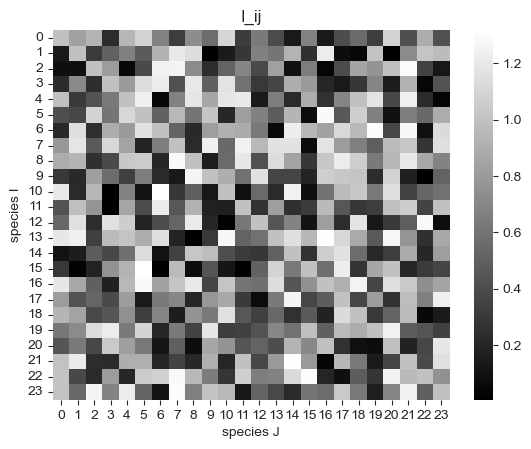

In [4]:
matrix = I[0:2*num_S, 0:2*num_S]

# Plot heatmap of the matrix using seaborn
ax = sns.heatmap(matrix, cmap='gray')

# Set x and y axis labels
ax.set_xlabel('species J')
ax.set_ylabel('species I')
ax.set_title('I_ij')

(array([9095., 8988., 8892., 9049., 8939., 9069., 8920., 9254., 8958.,
        8835.]),
 array([1.03667513e-06, 1.31999411e-01, 2.63997786e-01, 3.95996161e-01,
        5.27994536e-01, 6.59992911e-01, 7.91991285e-01, 9.23989660e-01,
        1.05598804e+00, 1.18798641e+00, 1.31998478e+00]),
 <BarContainer object of 10 artists>)

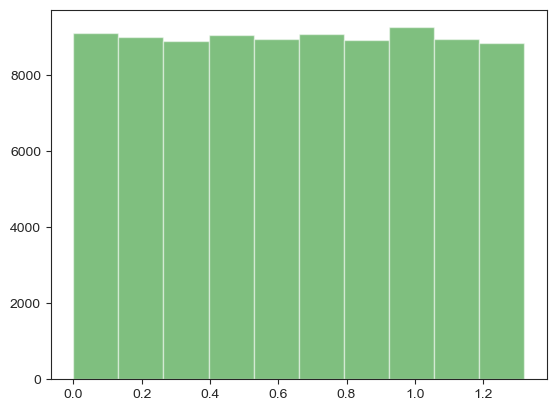

In [5]:
A=I.flatten().tolist()
A.remove(1.0)
plt.hist(A,bins=10, alpha=0.5, color='green')

In [21]:

DominanceMatrix_BC=np.zeros([num_C,num_C])
DominanceMatrix_J=np.zeros([num_C,num_C])
DominanceMatrix_JS=np.zeros([num_C,num_C])

threshold=0.0001
y_list=np.zeros([num_C,N])
for i in range(num_C):
    y=np.random.rand(N)*0.1
    y=run_lotka_volterra(y, np.linspace(0, 500, 3500), CommunitiesLibrary[i,:], I, g, k)
    y[y<threshold]=0
    y_list[i,:]=y

for i in range(num_C):
    for j in range(i,num_C):#range(i,num_C):
        y1= y_list[i,:]
        y2= y_list[j,:]

        
        y3=run_lotka_volterra((y1+y2)/2, np.linspace(0, 500, 3500), (y1+y2)>threshold, I, g, k)
        y3[y3<threshold]=0

        DominanceMatrix_BC[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))
        DominanceMatrix_BC[j,i]=1-DominanceMatrix_BC[i,j]
        DominanceMatrix_J[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJ(x,y,z)))
        DominanceMatrix_J[j,i]=1-DominanceMatrix_J[i,j]
        DominanceMatrix_JS[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJS(x,y,z)))
        DominanceMatrix_JS[j,i]=1-DominanceMatrix_JS[i,j]


        

In [29]:
1*(y3[0,:]<y3[100,:])

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


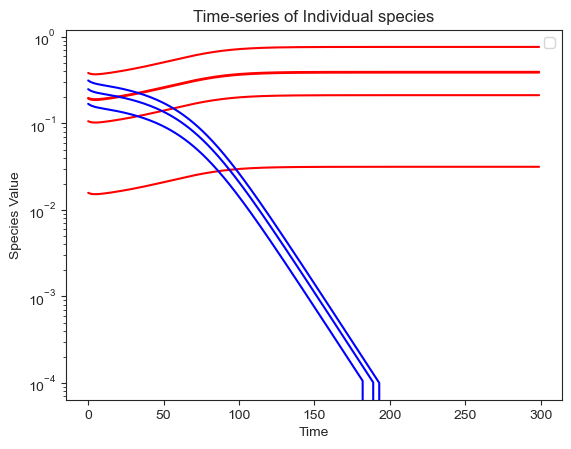

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


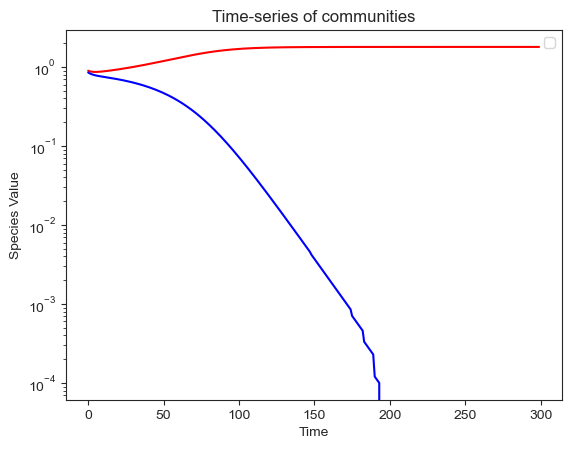

In [34]:
I_copy=u*np.ones(np.shape(I))
for i in range(num_C):
    I_copy[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]=I[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]

i=0
j=1
y1= y_list[i,:]
y2= y_list[j,:]
y3=run_lotka_volterra_dynamics((y1+y2)/2, np.linspace(0, 2500, 7500), (y1+y2)>threshold, I_copy, g, k)
y3[y3<threshold]=0

time_range=300
time=np.arange(time_range)
data=y3
flag_matrix=(y3[0,:]<y3[100,:])
color_list = ['blue' if flag_matrix[i] == 0 else 'red' for i in range(8)]

for i in range(8):
    plt.plot(time, data[:time_range, i],color=color_list[i])

# Set the x and y axis labels and title
plt.xlabel('Time')
plt.ylabel('Species Value')
plt.title('Time-series of Individual species')
plt.yscale('log')
# Add a legend
plt.legend()
plt.axis

# Show the plot
plt.show()


sum_A=sum(y3[:,flag_matrix],1)
sum_B=sum(y3[:,~flag_matrix],1)

#for ratio in np.arange(0,1,0.05):

plt.plot(time, sum_A[:time_range],color='red')
plt.plot(time, sum_B[:time_range],color='blue')


# Set the x and y axis labels and title
plt.xlabel('Time')
plt.ylabel('Species Value')
plt.title('Time-series of communities')
plt.yscale('log')
# Add a legend
plt.legend()
plt.axis

# Show the plot
plt.show()  

In [62]:
(np.concatenate([np.ones(5),np.zeros(5)]))

True

1.7952068544548796 1.7052876359556715


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


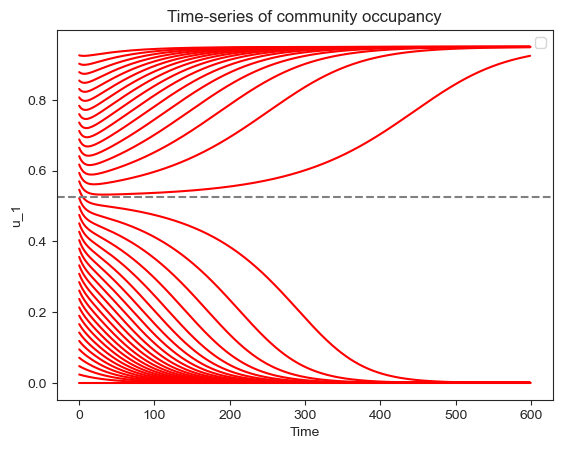

In [73]:
I_copy=u*np.ones(np.shape(I))
for i in range(num_C):
    I_copy[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]=I[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]

i=0
j=1
y1= y_list[i,:]
y2= y_list[j,:]
sum_A_max=sum(y1)
sum_B_max=sum(y2)
print(sum_A_max,sum_B_max)

for ratio in np.arange(0,1,0.025):
    y3=run_lotka_volterra_dynamics((ratio*y1+(1-ratio)*y2), np.linspace(0, 500, 3500), (ratio*y1+(1-ratio)*y2)>threshold, I_copy, g, k)
    y3[y3<threshold]=0

    time_range=600
    time=np.arange(time_range)
    flag_matrix=np.concatenate([np.ones(5),np.zeros(5)])
    flag_matrix = np.array([True if flag_matrix[i] == 0 else False for i in range(shape(y3)[1])])
    sum_A=np.sum(y3[:,flag_matrix],1)
    sum_B=np.sum(y3[:,~flag_matrix],1)
    u_1=sum_A/sum_A_max

    plt.plot(time, u_1[:time_range],color='red')



# Set the x and y axis labels and title
plt.xlabel('Time')
plt.ylabel('u_1')
plt.title('Time-series of community occupancy')
v=sum_A_max**2/(sum_A_max**2+sum_B_max**2)
plt.axhline(y=v, color='gray', linestyle='--')
#plt.yscale('log')
# Add a legend
plt.legend()
plt.axis

# Show the plot
plt.show()  